In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin


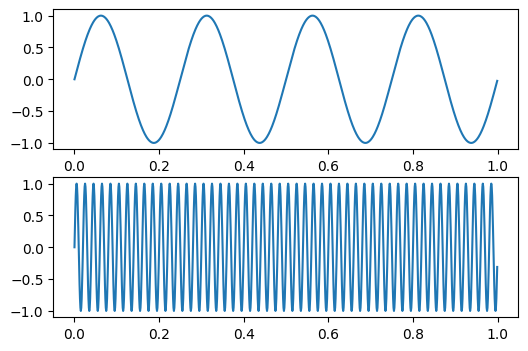

In [3]:
t = np.arange(0,1,0.001)
f1 = 4
f2 = 50
x1 = np.sin(2 * np.pi * f1 * t)
x2 = np.sin(2 * np.pi * f2 * t)
plt.figure(figsize=(6,4))
plt.subplot(2,1,1)
plt.plot(t,x1)
plt.subplot(2,1,2)
plt.plot(t,x2)
plt.show()

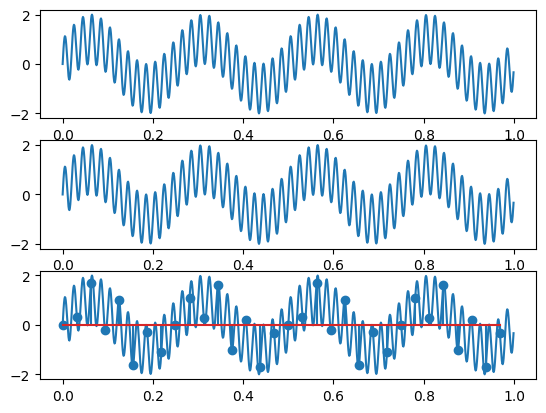

In [4]:
# Sampling
x = x1 + x2
fs = 32
n = np.arange(0,1, 1/fs)
x_sampled = np.sin(2*np.pi*f1*n) + np.sin(2*np.pi*f2*n)
plt.subplot(3,1,1)
plt.plot(t,x)
plt.subplot(3,1,2)
plt.plot(t,x)
plt.subplot(3,1,3)
plt.plot(t,x)
plt.stem(n,x_sampled)
plt.show()

Is same? True


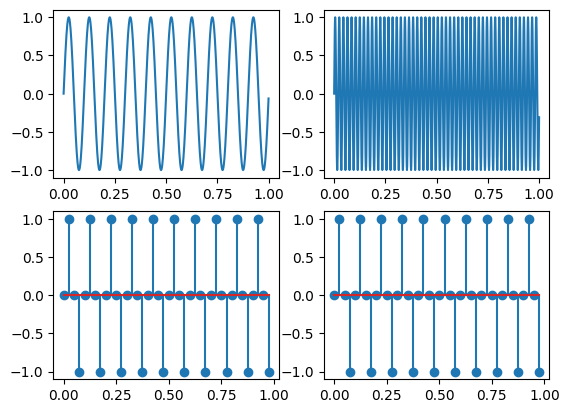

In [5]:
# Alising effect
# Show that 50 Hz is an alias of the frequency 10 Hz, when sampling at 40 Hz. Assume the signals are
t = np.arange(0, 1, 0.001)
f1 = 10
f2 = 50
x1 = np.sin(2 * np.pi * f1 * t)
x2 = np.sin(2 * np.pi * f2 * t)
plt.subplot(2,2,1)
plt.plot(t, x1)
plt.subplot(2, 2, 2)
plt.plot(t, x2)

#Sampling with 40 hz
fs = 40
n = np.arange(0,1, 1/fs)
x1_sampled = np.sin(2 * np.pi * f1 * n)
plt.subplot(2,2,3)
plt.stem(n, x1_sampled)

x2_sampled = np.sin(2 * np.pi * 50 * n)
plt.subplot(2,2,4)
plt.stem(n, x2_sampled)

# See difference - check is same
check = np.allclose(x1_sampled, x2_sampled)   # Check is same
print("Is same?" , check)

$$(f * g)(t) = \int_{-\infty}^{\infty} f(\tau) g(t-\tau) \, d\tau$$


In [ ]:
# Convulation 
def convulate(x, h, mode = "full"):
    len_x = len(x)
    len_h = len(h)

    len_y = len_x + len_h -1
    y = np.zeros(len_y, dtype="int")

    for n in range(len_y):
        for k in range(len_x):
            if 0 <= n - k < len_h:
                y[n] += x[k] * h[n - k]

    # -------------------------
    # MODE HANDLING
    # -------------------------

    if mode == "full":
        return y

    elif mode == "same":
        start = (len_h - 1) // 2
        return y[start:start + len_x]

    elif mode == "valid":
        start = len_h - 1
        end = len_full - (len_h - 1)
        return y[start:end]

    else:
        raise ValueError("Mode must be: full, same, or valid")


# Test
x = np.array([1, 2, 3])
h = np.array([1, 1, 1])

# Check is equal
print(convulate(x,h), np.convolve(x,h))

[1 3 6 5 3] [1 3 6 5 3]


In [7]:
def circular_convulation(x, h):
    len_x = len(x)
    len_h = len(h)

    len_y = max(len_x, len_h)

    #Zero padding
    x = np.pad(x, (0, len_y - len_x))
    h = np.pad(h, (0, len_y - len_h))

    y = np.zeros(len_y)

    for n in range(len_y):
        for k in range(len_y):
            y[n] += x[k] * h[(n - k) % len_y]
    return y

# Test
x = [1,2,3]
h = [1,1,1]

print(circular_convulation(x,h), np.fft.ifft(np.fft.fft(x, len(x)) * np.fft.fft(h,len(h)), len(x)))

[6. 6. 6.] [6.+0.j 6.+0.j 6.+0.j]


In [8]:
# Correlation
def correlate(x,h):
    return convulate(x,h[::-1])

# Test
x = [1,2,3]
h = [1,1,1]
print(correlate(x,h), np.correlate(x,h, mode="full"))

[1 3 6 5 3] [1 3 6 5 3]


## DFT


$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j\frac{2\pi kn}{N}}$


True


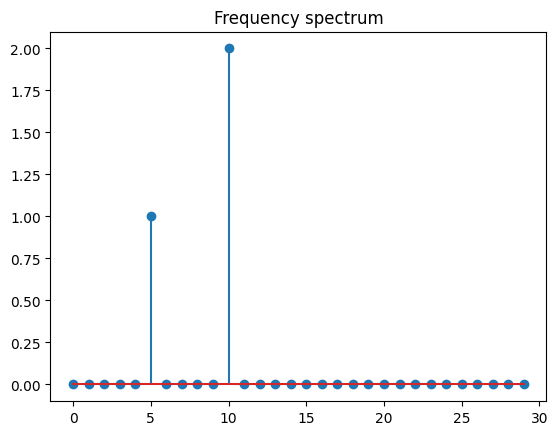

In [20]:
def dft(x, N):
    y = np.zeros(N, dtype="complex")
    
    for k in range(N):
        for n in range(N):
            y[k] += x[n] * np.exp(-1j * 2 * np.pi * n * k /N)

    return y

# Test
n  = np.arange(0,1,0.01)
x = np.sin( 2 * np.pi * 5 * n) + 2* np.sin(2 * np.pi * 10 * n)

X = dft(x, len(x))

plt.title("Frequency spectrum")
plt.stem(np.abs(X)[:30]/(len(X)/2))
# Extra test
Xp = np.fft.fft(x,len(x))
print(np.allclose(X, Xp))

<StemContainer object of 3 artists>

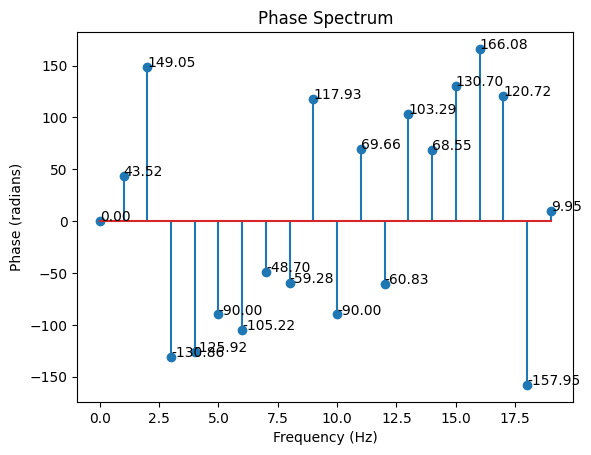

In [35]:
phase = np.angle(X)
phase = np.degrees(phase)
plt.title("Phase Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (radians)")
for i in range(20):
    plt.text(i, phase[i], f"{phase[i]:.2f}")
plt.stem(range(0,20), phase[:20])

In [37]:
# idft implementation
def idft(X,N):
    x = np.zeros(N, dtype="complex")

    for n in range(N):
        for k in range(N):
            x[n] += X[k] * np.exp(1j * 2 * np.pi * n * k /N)
    return x/N

x_reconstruct = idft(X, len(X))

print(np.allclose(x, x_reconstruct.real))

True


In [40]:
# idft implementation
def idft(X,N):
    x = np.zeros(N , dtype="complex")

    for n in range(N):
        for k in range(N):
            x[n] += X[k] * np.exp(1j * 2 * np.pi * n * k /N)
    return x/N

x_reconstruct = idft(X, len(X))
print(np.allclose(x_reconstruct,np.fft.ifft(X)))
print(np.allclose(x, x_reconstruct.real))

True
True


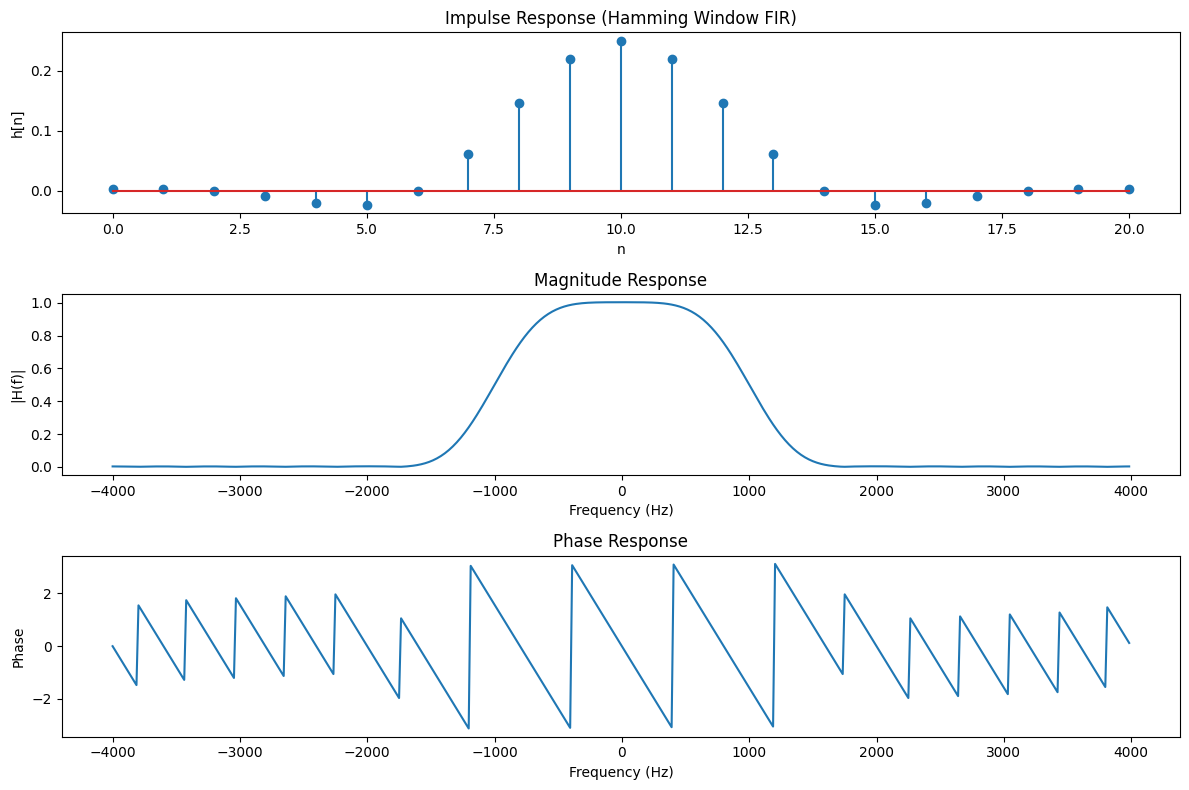

In [4]:
# Filter
import numpy as np
import matplotlib.pyplot as plt

# Given
fs = 8000
fc = 1000
N = 21

# Parameters
M = (N - 1) // 2
n = np.arange(N)

fc_norm = fc / fs  # IMPORTANT

# -----------------------------
# 1. Ideal Impulse Response
# -----------------------------
h_ideal = np.zeros(N)

for i in range(N):
    if i == M:
        h_ideal[i] = 2 * fc_norm
    else:
        h_ideal[i] = np.sin(2 * np.pi * fc_norm * (i - M)) / (np.pi * (i - M))

# -----------------------------
# 2. Hamming Window
# -----------------------------
w = 0.54 - 0.46 * np.cos(2 * np.pi * n / (N - 1))

# -----------------------------
# 3. Apply Window
# -----------------------------
h = h_ideal * w

# -----------------------------
# 4. Frequency Response
# -----------------------------
H = np.fft.fft(h, 512)
freq = np.fft.fftfreq(512, 1/fs)

# Shift for better visualization
H_shift = np.fft.fftshift(H)
freq_shift = np.fft.fftshift(freq)

# -----------------------------
# 🔹 PLOTS
# -----------------------------

plt.figure(figsize=(12,8))

# Impulse Response
plt.subplot(3,1,1)
plt.stem(n, h)
plt.title("Impulse Response (Hamming Window FIR)")
plt.xlabel("n")
plt.ylabel("h[n]")

# Magnitude Response
plt.subplot(3,1,2)
plt.plot(freq_shift, np.abs(H_shift))
plt.title("Magnitude Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("|H(f)|")

# Phase Response
plt.subplot(3,1,3)
plt.plot(freq_shift, np.angle(H_shift))
plt.title("Phase Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase")

plt.tight_layout()
plt.show()
